<a href="https://colab.research.google.com/github/fazmina11/fazmina-codeboosters-2026/blob/main/day2/Mini_project_day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/Copy of student_performance.csv');
conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql('students', conn, if_exists='replace', index=False)

30

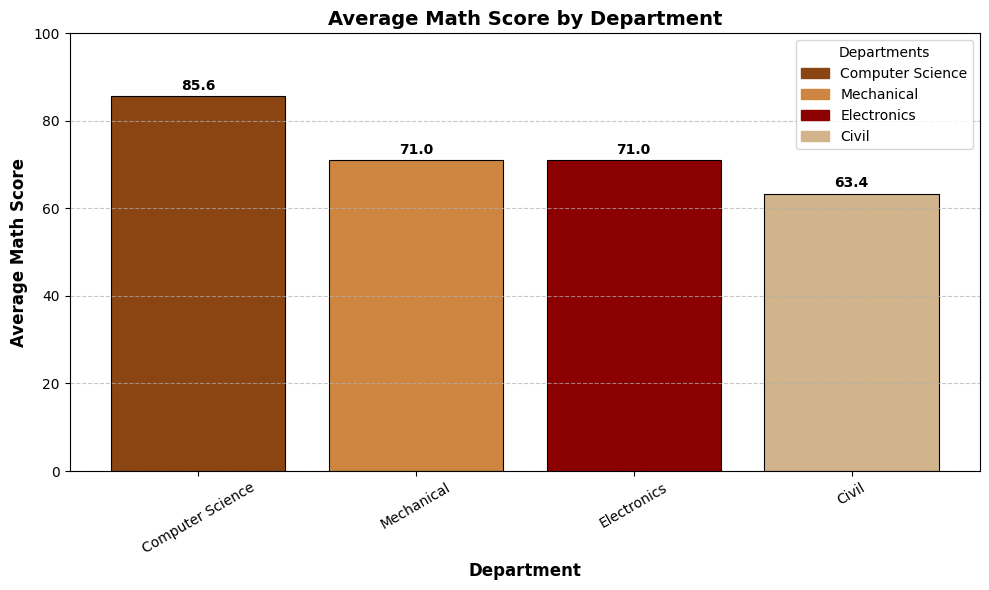

In [ ]:

chart1_sql = """
  SELECT department,
         ROUND(AVG(math_score), 2) AS avg_math
  FROM students
  GROUP BY department
  ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colours = ['saddlebrown', 'peru', 'darkred', 'tan', 'wheat']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colours[:len(chart1_data)],
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

ax.set_xlabel('Department', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Math Score', fontsize=12, fontweight='bold')
ax.set_title('Average Math Score by Department', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', labelsize=10)

legend_labels = chart1_data['department'].tolist()
legend_handles = [
    plt.Rectangle((0,0),1,1, color=bar_colours[i], edgecolor='black')
    for i in range(len(legend_labels))
]
ax.legend(legend_handles, legend_labels, title="Departments", loc="upper right")

plt.tight_layout()
plt.show()

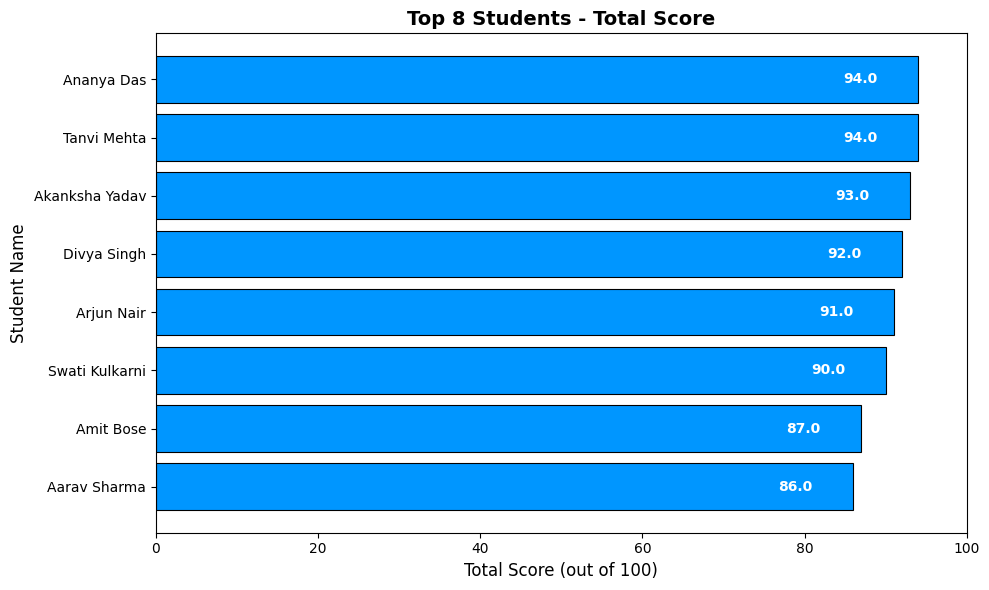

In [ ]:

chart_sql = """
  SELECT name,
         (math_score + science_score + programming_score + attendance_percentage)/4 AS total_score
  FROM students
  ORDER BY total_score DESC
  LIMIT 8
"""

chart_data = pd.read_sql_query(chart_sql, conn)
chart_data = chart_data.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    chart_data['name'],              # y-axis: student names
    chart_data['total_score'],       # x-axis: total score
    color='#0096FF',
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width - 5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}',
        ha='right',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

ax.set_xlabel('Total Score (out of 100)', fontsize=12,)
ax.set_ylabel('Student Name', fontsize=12,)
ax.set_title('Top 8 Students - Total Score', fontsize=14, fontweight='bold')

ax.set_xlim(0, 100)

ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

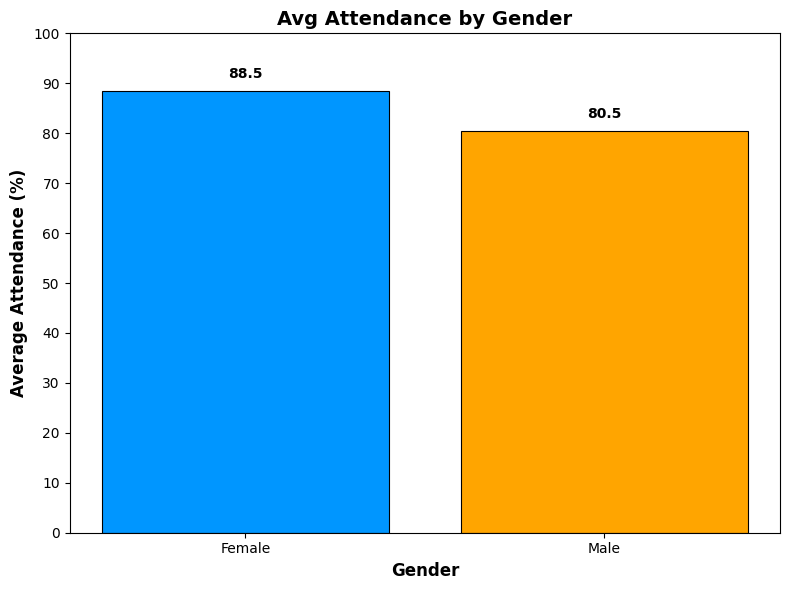

In [ ]:

chart_sql = """
  SELECT gender,
         ROUND(AVG(attendance_percentage), 2) AS avg_attendance
  FROM students
  GROUP BY gender
"""

chart_data = pd.read_sql_query(chart_sql, conn)

fig, ax = plt.subplots(figsize=(8, 6))

bar_colours = ['#0096FF', 'orange']

bars = ax.bar(
    chart_data['gender'],
    chart_data['avg_attendance'],
    color=bar_colours[:len(chart_data)],
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

ax.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Attendance (%)', fontsize=12, fontweight='bold')
ax.set_title('Avg Attendance by Gender', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))  # ticks from 0 to 100 in steps of 10
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

